---

# **Importing and File Reading**

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler, TargetEncoder
from sklearn.metrics import classification_report

In [88]:
df = pd.read_csv("../../../Data/loan_approval.csv")
df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


---

# **Creating object for LogisticRegression()**

```

class LogisticRegression(
    penalty: Literal['l1', 'l2', 'elasticnet'] | None = "l2",
    *,
    dual: bool = False,
    tol: Float = 0.0001,
    C: Float = 1,
    fit_intercept: bool = True,
    intercept_scaling: Float = 1,
    class_weight: Mapping | str | None = None,
    random_state: Int | RandomState | None = None,
    solver: Literal['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'] = "lbfgs",
    max_iter: Int = 100,
    multi_class: Literal['auto', 'ovr', 'multinomial'] = "auto",
    verbose: Int = 0,
    warm_start: bool = False,
    n_jobs: Int | None = None,
    l1_ratio: Float | None = None
)

```

<h3 style="color:#00FFFF"><b>Important Paramerters In Logistic Regression</b></h3>

> penalty: Literal['l1', 'l2', 'elasticnet'] | Default = "l2" (Ridge)

> solver: Literal['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'] = "lbfgs", use liblinear if want more than 2 results not just 0 and 1

|solver|	l1_ratio|	multinomial multiclass|
|---|---|---|
|'lbfgs'|	l1_ratio=0|	yes|
|'liblinear'|	l1_ratio=1 or l1_ratio=0	|no|
|'newton-cg'	|l1_ratio=0	|yes|
|'newton-cholesky'|	l1_ratio=0|	yes|
|'sag'	|l1_ratio=0	|yes|
|'saga'	|0<=l1_ratio<=1	|yes|

<br>

> **max_iter: Int = 100,** => to find the best weight it will take multiple iternation by default it uses 100 we can increase if number of features are more, Based on this grandation works

> **class_weight =>     class_weight: Mapping | str | None = None,** --> defalutl = None change to 'balanced' if |spam = 700 | not spam = 100| then it is imbalance find this using TargetCol_value_count() to balance the dataset or use Re-sampling for balancing


> **C: Float = 1,** ==> This will decide the model is going to be good fit orverfit or underfit


<h3 style="color:orange"><b>Note :=> If target column is continues values and we cant use classificatin algoithums</b> </h3>

# **Segerating Columns**

In [89]:
x = df.drop(columns="loan_approved")
y = df["loan_approved"]

# **Spliting the data**

In [90]:
Xtrain, Xtest, ytrain, ytest = train_test_split(x,y,random_state=42,train_size=0.8)

# **Checking for Co-Relation**

### Relation between features are weakly co-related 

In [91]:
x.corr(numeric_only=True)

,income,credit_score,loan_amount,years_employed,points
income,1.000000,-0.027113,0.037612,-0.014441,0.451142
credit_score,-0.027113,1.000000,-0.008076,0.023598,0.740899
loan_amount,0.037612,-0.008076,1.000000,0.013015,-0.223039
years_employed,-0.014441,0.023598,0.013015,1.000000,0.156441
points,0.451142,0.740899,-0.223039,0.156441,1.000000


# **Seperating Categorical and Numerical Columns**

**`Here we dont use df instead use X because df contain Target Columns also`**
**`We did this because we can easily apply pre-processing techique`**

In [92]:
num_col = x.select_dtypes(include="number").columns
obj_col = x.select_dtypes(include="string").columns

# **Checking for outlayers for scaling and Encoding**

In [93]:
x[obj_col].nunique()

name    2000
city    1882
dtype: int64

<Axes: >

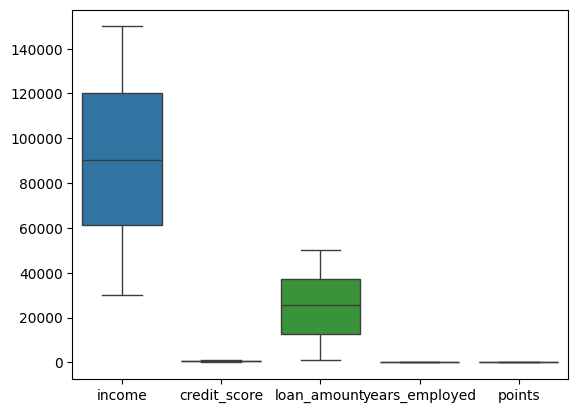

In [94]:
sns.boxplot(x[num_col])

# **Preprocessing Techniques**

### **-Scaling**
### **-Encoding**

### **Why Scaliing?**
`Feature cols values are in different range(scale). So we cann use scaling to equal importance for all the feature cols`


### **Why Encoing?**
`Algorithums can understand only numbers not strings`

### **Which scaling and Encoding Techniques we can use for this?**

Scaling - 1)`MinMaxScaler`,  2)`StandardScaler`

Encoding - `Target-Encoder`

In [95]:
df.sample()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
1399,Tracy Copeland,Bautistaport,65003,534,46954,5,30.0,False


# **Creating Models**

In [96]:
encoder = TargetEncoder()
scaling = MinMaxScaler()
model = LogisticRegression(penalty="l1", solver="liblinear")
model = LogisticRegression()

In [97]:
df[num_col].nunique()

income            1988
credit_score       537
loan_amount       1968
years_employed      41
points              19
dtype: int64

In [98]:
Xtrain[num_col] = scaling.fit_transform(Xtrain[num_col])

Xtrain[obj_col] = encoder.fit_transform(Xtrain[obj_col],ytrain)

Xtrain

,name,city,income,credit_score,loan_amount,years_employed,points
968,0.434375,0.434375,0.166123,0.298182,0.436429,0.600,0.166667
240,0.435156,0.000000,0.335691,0.378182,0.441473,0.125,0.277778
819,0.435156,1.000000,0.486970,0.905455,0.344529,0.525,0.833333
692,0.435156,0.435156,0.337625,0.121818,0.251567,0.725,0.388889
420,0.435156,0.435156,0.554653,0.841818,0.152112,0.150,0.833333
...,...,...,...,...,...,...,...
1130,0.435156,0.435156,0.601171,0.354545,0.968475,0.575,0.388889
1294,0.435156,0.435156,0.649982,0.321818,0.849644,0.000,0.277778
860,0.435156,0.435156,0.445088,0.507273,0.328624,0.500,0.444444
1459,0.435156,0.435156,0.860588,0.167273,0.246503,0.400,0.555556


In [99]:
Xtest[num_col] = scaling.transform(Xtest[num_col])

Xtest[obj_col] = encoder.transform(Xtest[obj_col])

Xtest

,name,city,income,credit_score,loan_amount,years_employed,points
1860,0.435,0.435,0.835928,0.267273,0.315944,0.250,0.500000
353,0.435,0.435,0.200123,0.923636,0.187741,0.525,0.833333
1333,0.435,0.435,0.629433,0.723636,0.635952,0.875,0.722222
905,0.435,0.435,0.366972,0.632727,0.114441,0.500,0.611111
1289,0.435,0.435,0.077608,0.912727,0.232068,0.750,0.666667
...,...,...,...,...,...,...,...
965,0.435,0.435,0.916897,0.185455,0.982073,0.600,0.444444
1284,0.435,0.435,0.162412,0.516364,0.951385,0.225,0.277778
1739,0.435,0.435,0.791178,0.056364,0.111460,0.500,0.555556
261,0.435,0.435,0.289281,0.803636,0.248076,0.925,0.777778


In [100]:
model.fit(Xtrain, ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [101]:
yPred_train = model.predict(Xtrain)
yPred_train

array([False, False,  True, ..., False, False, False], shape=(1600,))

In [102]:
yPred_test = model.predict(Xtest)
yPred_test

array([False,  True,  True,  True,  True,  True, False,  True, False,
        True, False,  True,  True, False, False,  True, False, False,
       False, False,  True, False, False, False,  True,  True,  True,
       False,  True, False, False,  True, False,  True, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False,  True,  True, False, False, False,
        True, False,  True, False, False,  True, False, False, False,
        True, False, False,  True, False,  True,  True, False, False,
        True, False,  True, False,  True,  True, False,  True,  True,
        True,  True,  True, False, False,  True,  True,  True, False,
       False,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True, False, False,  True, False, False, False, False,
        True, False, False, False, False, False, False, False,  True,
       False, False, False,  True,  True, False, False,  True,  True,
       False, False,

# **Model Evaluation**

### **R2_score**

In [103]:
model.score(Xtrain,ytrain)

0.96125

---

### **Confusion_matrix**

`Here we can see model performace is good and predicting majority of data correctly. Note we cant see any percentage but from the given array we can conclude out of 225 negative labled it predicted 210 lables correctly`

In [104]:
matrix = confusion_matrix(ytest,yPred_test)
matrix

array([[210,   7],
       [ 15, 168]])

In [105]:
Pred_Fasle = sum(matrix[:,0])
Pred_True = sum(matrix[1,:])
Pred_True

np.int64(183)

### **Conclusion**

`out of all the preicted "False" lables(225), 93% lables are corrctly predicted as False`

`out of all the preicted "True" lables(183), 91% lables are corrctly predicted as True`

---

### **Precision_score for positive**

`Here we can see model performace is good and predicting 96% of data correcty`

In [106]:
precision_score(ytest, yPred_test, pos_label=1)

0.96

### **precision_score for negative**

`Here we can see model performace is good and predicting 93% of data correcty`

In [107]:
precision_score(ytest, yPred_test, pos_label=0)

0.9333333333333333

### **Conclusion**

`out of all the preicted "False" lables(225), 93% lables are corrctly predicted as False`

`out of all the preicted "True" lables(183), 96% lables are corrctly predicted as True`

---

### **Recall Score for positive**

`Here we can see model performace is good and predicting 91% of data correcty`

In [108]:
recall_score(ytest, yPred_test, pos_label=1)

0.9180327868852459

### **Recall Score for negative**

`Here we can see model performace is good and predicting 96.7% of data correcty`

In [109]:
recall_score(ytest, yPred_test, pos_label=0)

0.967741935483871

### **Accuracy Score for positive**

`Here we can see model performace is good and predicting 94.25% of data correcty`

In [110]:
accuracy_score(ytest, yPred_test)

0.945

### **F1 Score for positive**

`Here we can see model performace is good and predicting 96.7%, 95% of data correcty`

In [111]:
f1_score(ytest, yPred_test, pos_label=1)

0.9385474860335196

In [112]:
f1_score(ytest, yPred_test, pos_label=0)

0.9502262443438914

In [113]:
y_test_pred = model.predict(Xtest)

In [114]:
model.score(Xtest, ytest)

0.945

# **Report of all Evalutation**

<h4 style="color:orange"><b>Note:=> </b>use this instead of all the above because it will give total table for metrix</h4>


In [115]:
print(classification_report(ytrain, yPred_train))

              precision    recall  f1-score   support

       False       0.96      0.98      0.97       904
        True       0.97      0.94      0.95       696

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600

